In [ ]:
!pip install -q tensorflow opencv-python matplotlib seaborn pandas scikit-learn kaggle

step1:

In [ ]:
#step1
import os
import cv2
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

metadata_path = "/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_metadata.csv"

df = pd.read_csv(metadata_path)

print(df.shape)
df.head()

(10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [ ]:
import glob

folder1 = "/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1"
folder2 = "/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/ham10000_images_part_1"

images = glob.glob(folder1 + "/*.jpg") + glob.glob(folder2 + "/*.jpg")

print("Images found:", len(images))
print(images[:5])

Images found: 6325
['/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028306.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028307.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028308.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028309.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028310.jpg']


In [ ]:
import os

base = "/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant"

for root, dirs, files in os.walk(base):
    level = root.replace(base, "").count(os.sep)
    indent = " " * 2 * level
    print(indent + os.path.basename(root) + "/")
    if level < 3:
        for f in files[:5]:
            print("  " + f)

AI_Skin_Disease_Consultant/
  HAM10000_metadata.csv
  best_skin_model.keras
  HAM10000_images_part_1/
  ISIC_0028306.jpg
  ISIC_0028307.jpg
  ISIC_0028308.jpg
  ISIC_0028309.jpg
  ISIC_0028310.jpg
  HAM10000_images_part_2/
  ISIC_0033513.jpg
  ISIC_0033514.jpg
  ISIC_0033515.jpg
  ISIC_0033516.jpg
  ISIC_0033517.jpg
  ham10000_images_part_1/
  ISIC_0024643.jpg
  ISIC_0024644.jpg
  ISIC_0024645.jpg
  ISIC_0024646.jpg
  ISIC_0024647.jpg
  HAM10000/
  HAM10000_metadata.csv
    HAM10000_images_part_1/
  ISIC_0028306.jpg
  ISIC_0028307.jpg
  ISIC_0028308.jpg
  ISIC_0028309.jpg
  ISIC_0028310.jpg
    HAM10000_images_part_2/
  ISIC_0033321.jpg
  ISIC_0033322.jpg
  ISIC_0033323.jpg
  ISIC_0033324.jpg
  ISIC_0033325.jpg
    ham10000_images_part_1/
  ISIC_0028306.jpg
  ISIC_0028307.jpg
  ISIC_0028308.jpg
  ISIC_0028309.jpg
  ISIC_0028310.jpg
    ham10000_images_part_2/
  ISIC_0033284.jpg
  ISIC_0033285.jpg
  ISIC_0033286.jpg
  ISIC_0033287.jpg
  ISIC_0033288.jpg


In [ ]:
import os

base = "/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant"

for root, dirs, files in os.walk(base):
    print("\nFolder:", root)
    print("Subfolders:", dirs[:10])
    print("Files:", files[:5])


Folder: /content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant
Subfolders: ['HAM10000_images_part_1', 'HAM10000_images_part_2', 'ham10000_images_part_1', 'HAM10000']
Files: ['HAM10000_metadata.csv', 'best_skin_model.keras']

Folder: /content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1
Subfolders: []
Files: ['ISIC_0028306.jpg', 'ISIC_0028307.jpg', 'ISIC_0028308.jpg', 'ISIC_0028309.jpg', 'ISIC_0028310.jpg']

Folder: /content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_2
Subfolders: []
Files: ['ISIC_0033513.jpg', 'ISIC_0033514.jpg', 'ISIC_0033515.jpg', 'ISIC_0033516.jpg', 'ISIC_0033517.jpg']

Folder: /content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/ham10000_images_part_1
Subfolders: []
Files: ['ISIC_0024643.jpg', 'ISIC_0024644.jpg', 'ISIC_0024645.jpg', 'ISIC_0024646.jpg', 'ISIC_0024647.jpg']

Folder: /content/drive/MyDrive/AI_Skin_Disease _

In [ ]:
import glob
import os

base = "/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant"

folder1 = os.path.join(base, "/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1")
folder2 = os.path.join(base, "/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_2")

images = glob.glob(folder1 + "/*.jpg") + glob.glob(folder2 + "/*.jpg")

print("Images found:", len(images))
print(images[:3])


Images found: 10014
['/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028306.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028307.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028308.jpg']


In [ ]:
import glob
import os

base = "/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant"

folder1 = os.path.join(base, "HAM10000_images_part_1")
folder2 = os.path.join(base, "HAM10000_images_part_2")

images = glob.glob(folder1 + "/*.jpg") + glob.glob(folder2 + "/*.jpg")

print("Images found:", len(images))
print(images[:5])

Images found: 10014
['/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028306.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028307.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028308.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028309.jpg', '/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0028310.jpg']


In [ ]:
print(len(df))
print(df.head())

10015
     lesion_id      image_id   dx dx_type   age   sex localization
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear


In [ ]:
import os

image_dict = {
    os.path.splitext(os.path.basename(img))[0]: img
    for img in images
}

df["image_path"] = df["image_id"].map(image_dict)

print(df.head())
print("Missing image paths:", df["image_path"].isna().sum())

     lesion_id      image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633  bkl   histo  75.0  male          ear   

                                          image_path  
0  /content/drive/MyDrive/AI_Skin_Disease _Consul...  
1  /content/drive/MyDrive/AI_Skin_Disease _Consul...  
2  /content/drive/MyDrive/AI_Skin_Disease _Consul...  
3  /content/drive/MyDrive/AI_Skin_Disease _Consul...  
4  /content/drive/MyDrive/AI_Skin_Disease _Consul...  
Missing image paths: 1


In [ ]:
df = df.dropna(subset=["image_path"])

print(df.shape)

(10014, 8)


In [ ]:
print(df["image_path"].iloc[0])

/content/drive/MyDrive/AI_Skin_Disease _Consultant /AI_Skin_Disease_Consultant/HAM10000_images_part_1/ISIC_0027419.jpg


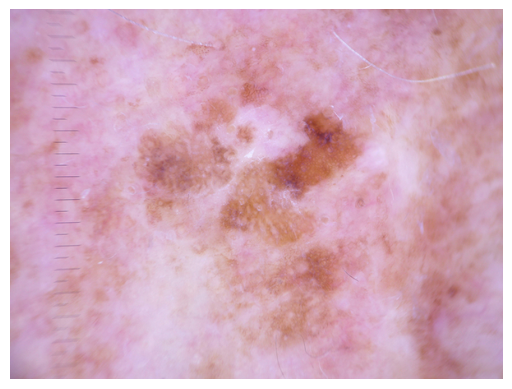

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(df["image_path"].iloc[0])

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from PIL import Image
import os

bad_images = []

for path in df["image_path"]:
    try:
        img = Image.open(path)
        img.verify()
    except:
        bad_images.append(path)

print("Corrupted images:", len(bad_images))

NameError: name 'df' is not defined

In [ ]:
(df['dx'].value_counts(normalize=True) * 100).round(2)

,proportion
dx,
nv,66.95
mel,11.11
bkl,10.97
bcc,5.13
akiec,3.27
vasc,1.42
df,1.15


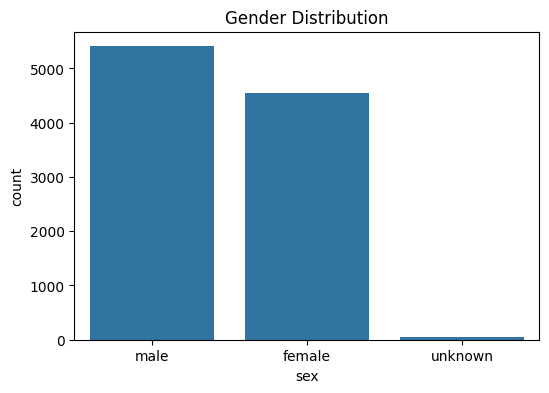

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x='sex')

plt.title("Gender Distribution")

plt.show()

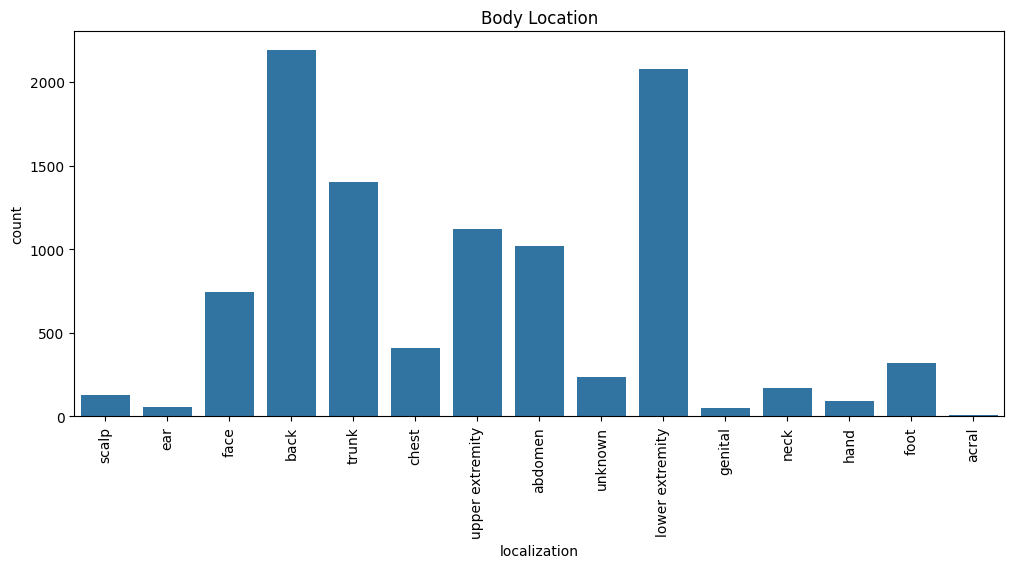

In [ ]:
plt.figure(figsize=(12,5))

sns.countplot(data=df, x='localization')

plt.xticks(rotation=90)

plt.title("Body Location")

plt.show()

In [ ]:
import glob
import os

image_paths = {}

# Debugging step: List contents of /content/ to see the extracted folder names
print("Contents of /content/:", os.listdir("/content/"))

# Correcting the folder paths based on the output of os.listdir("/content/")
# It appears HAM10000_images_part_1 and HAM10000_images_part_2 are directly in /content/
folders = [
    "/content/HAM10000_images_part_1",
    "/content/HAM10000_images_part_2"
]

for folder in folders:
    for img in glob.glob(os.path.join(folder, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(img))[0]
        image_paths[image_id] = img

print("Total images found:", len(image_paths))

Contents of /content/: ['.config', 'hmnist_8_8_RGB.csv', 'HAM10000_images_part_1', 'skin-cancer-mnist-ham10000.zip', 'ham10000_images_part_1', 'drive', 'hmnist_8_8_L.csv', 'hmnist_28_28_RGB.csv', 'hmnist_28_28_L.csv', 'ham10000_images_part_2', 'HAM10000_images_part_2', 'HAM10000_metadata.csv', 'sample_data']
Total images found: 10015


In [ ]:
df["image_path"] = df["image_id"].map(image_paths)

df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path,label


In [ ]:
print(df["image_path"].isnull().sum())

0


In [ ]:
print(df.columns)

Index(['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization',
       'image_path', 'label'],
      dtype='object')


In [ ]:
print(df["image_path"].head(10))

Series([], Name: image_path, dtype: object)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/AI_Skin_Disease_Consultant"

print(os.listdir(DATASET_PATH))

[]


In [ ]:
import os
import glob

DATASET_PATH = "/content/drive/MyDrive/AI_Skin_Disease_Consultant"

image_paths = {}

for folder in ["HAM10000_images_part_1", "HAM10000_images_part_2"]:
    files = glob.glob(os.path.join(DATASET_PATH, folder, "*.jpg"))
    for file in files:
        image_id = os.path.splitext(os.path.basename(file))[0]
        image_paths[image_id] = file

print("Images found:", len(image_paths))

Images found: 0


In [ ]:
df["image_path"] = df["image_id"].map(image_paths)

missing = df[df["image_path"].isna()]

print("Missing images:", len(missing))
missing[["image_id"]]

Missing images: 0


,image_id


In [ ]:
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Missing image paths:", df["image_path"].isnull().sum())

Dataset shape: (0, 8)
Missing image paths: 0


In [ ]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["label"] = encoder.fit_transform(df["dx"])

print(encoder.classes_)
print(df[["dx", "label"]].head())

[]
Empty DataFrame
Columns: [dx, label]
Index: []


In [ ]:
label_mapping = dict(zip(encoder.classes_,
                         encoder.transform(encoder.classes_)))

print(label_mapping)

{}


In [ ]:
#Now run the Train/Validation/Test Split
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)
print("Test Shape:", test_df.shape)

ValueError: With n_samples=0, test_size=0.3 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

test_datagen = ImageDataGenerator()

In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col="image_path",
    y_col="dx",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 7009 validated image filenames belonging to 7 classes.
Found 1502 validated image filenames belonging to 7 classes.
Found 1503 validated image filenames belonging to 7 classes.


step2:


In [ ]:
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

print(tf.__version__)

2.20.0


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(train_df["label"])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.372426699937617), 1: np.float64(2.7813492063492062), 2: np.float64(1.3020620471855842), 3: np.float64(12.51607142857143), 4: np.float64(1.2853475151292866), 5: np.float64(0.2133572798392743), 6: np.float64(10.113997113997113)}


In [ ]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(512, activation="relu")(x)

x = Dropout(0.5)(x)

outputs = Dense(7, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

In [ ]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,714,154 (17.98 MB)

 Trainable params: 662,023 (2.53 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath="/content/drive/MyDrive/AI_Skin_Disease_Consultant/best_skin_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    verbose=1
)

In [ ]:
#train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ]
)

Epoch 1/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.3757 - loss: 2.5815
Epoch 1: val_accuracy improved from None to 0.64847, saving model to /content/drive/MyDrive/AI_Skin_Disease_Consultant/best_skin_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/AI_Skin_Disease_Consultant/best_skin_model.keras
220/220 ━━━━━━━━━━━━━━━━━━━━ 2625s 12s/step - accuracy: 0.3996 - loss: 2.3694 - val_accuracy: 0.6485 - val_loss: 1.2125 - learning_rate: 0.0010
Epoch 2/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4586 - loss: 2.0396
Epoch 2: val_accuracy did not improve from 0.64847
220/220 ━━━━━━━━━━━━━━━━━━━━ 857s 4s/step - accuracy: 0.4760 - loss: 1.9245 - val_accuracy: 0.4368 - val_loss: 1.7372 - learning_rate: 0.0010
Epoch 3/15
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.4953 - loss: 1.6935
Epoch 3: val_accuracy did not improve from 0.64847

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
220/220 ━━━━━━━━━━━━━━━━━━━━ 8

In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Calculate class weights to handle class imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)

# Convert class weights to a dictionary format
class_weight_dict = dict(enumerate(class_weights))

history1 = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=15,

    callbacks=[
        early_stop,
        checkpoint,
        reduce_lr
    ],

    class_weight=class_weight_dict

)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)


plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

plt.title("Training vs Validation Accuracy")

plt.show()

In [ ]:
#Plot Loss Curve
plt.figure(figsize=(8,5))


plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)


plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.title("Training vs Validation Loss")

plt.show()

In [ ]:
from tensorflow.keras.models import load_model

model_path = "/content/drive/MyDrive/AI_Skin_Disease_Consultant/best_skin_model.keras"

model = load_model(model_path)

print("Model loaded successfully")

In [ ]:
base_model.trainable = False

In [ ]:
base_model.trainable = True

In [ ]:
for layer in base_model.layers[:-30]:
    layer.trainable = False

step4:

In [ ]:
#evaluate on test dataset
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)